In [1]:
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive', force_remount = False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
##########################################################################################
#  RUN THIS CELL ONLY IN COLLAB! IT IS ONLY TO DOWNLOAD SOME COOL FONTS.                 #
#  AFTER RUN IT IS NECESSARY TO RESTART THE SESSION AN RUN THE OTHER CELLS.              #
##########################################################################################
!echo ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true | debconf-set-selections

#Update and install the fonts silently
!apt-get update -qq
!apt-get install -y -qq ttf-mscorefonts-installer

#Rebuild the system font cache
!fc-cache -fv

#Reliably clear the Matplotlib font cache
import matplotlib
import shutil
import os

cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"\nCleared Matplotlib cache at: {cache_dir}")

print("\n FONTS INSTALLED! Please go to the top menu: Runtime -> Restart Session (or Restart Runtime) before running Cell 3.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package libmspack0:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../00-libmspack0_0.10.1-2build2_amd64.deb ...
Unpacking libmspack0:amd64 (0.10.1-2build2) ...
Selecting previously unselected package cabextract.
Preparing to unpack .../01-cabextract_1.9-3_amd64.deb ...
Unpacking cabextract (1.9-3) ...
Selecting previously unselected package xfonts-encodings.
Preparing to unpack .../02-xfonts-encodings_1%3a1.0.5-0ubuntu2_all.deb ...
Unpacking xfonts-encodings (1:1.0.5-0ubuntu2) ...
Selecting previously unselected package xfonts-utils.
Preparing to unpack .../03-xfonts-utils_1%3a7.7+6build2_amd64.deb ...
Unpacking xfonts-utils (1:7.7+6build2) ...
Selecting previously unselected package pyth

In [113]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown
!pip -q install pylhe


import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')
import glob
import gc
import seaborn as sns



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/develop/helpers.py

# Force-download the Z prime constraints:
!wget -q -O Safe_Limits_Zprime.csv https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/develop/Recast/Zprime/Safe_Limits_Zprime.csv

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 14, "axes.labelsize": 15, "axes.titlesize": 15,
    "legend.fontsize": 11, "xtick.labelsize": 12, "ytick.labelsize": 12,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",  "mathtext.rm": "serif",
    "mathtext.it": "serif:italic", "mathtext.bf": "serif:bold",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}



plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['figure.max_open_warning'] = 50
pd.option_context('display.max_columns', -1)


pd.options.mode.chained_assignment = None #Disable copy warnings


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.9, rc={
    "axes.labelsize": 19,
    "axes.titlesize": 19,
    "legend.title_fontsize": 14,
    "legend.fontsize": 13,
})
cm = plt.colormaps['RdYlBu']

 # Load the data, perform the best fit for the mass and signal strength per systematic value

In [136]:

# Define Fake Data file paths
fake_data_files = (
    list(glob.glob('./drive/MyDrive/Distributions/Scalar/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1500_mSDM_1400.npz')) +
    list(glob.glob('./drive/MyDrive/Distributions/Scalar/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1500_mSDM_1400.npz'))
)

# Define the array of systematic errors and luminosities
systematics = [0.0, 0.02, 0.05, 0.10]
luminosities = np.array([300, 500, 1000, 1500, 2000, 2500, 3000])

fitted_data = hp.fit_and_assemble_data(
    fake_data_files=fake_data_files,
    sys_err_list=systematics,
    lumi=500.0,
    base_dir='./drive/MyDrive/Distributions'
)
df_sm = fitted_data[0.0]['df_sm']
df_bsm = fitted_data[0.0]['df_bsm']

# Run the Falloff / Shape scanning engine using the dictionary
results_df = hp.run_fast_lumi_scan(
    fitted_data_dict=fitted_data,
    labels=["Scalar", "VLF", "Zprime", "Zprime_20pc"],
    target_mcut=1500,
    mcut_max=4500,
    bin_width=100,
    lumi_targets=luminosities,
    sys_err_list=systematics,
    fake_model='FakeData'
)

#Pull the baseline best_fits (usually 0.0) to print the mass labels on the plot titles
baseline_fits = fitted_data[0.0]['best_fits'] if 0.0 in fitted_data else fitted_data[list(fitted_data.keys())[0]]['best_fits']



Fake Data correctly normalized to yield: 1935.91 events in target window.

 Fitting for Systematic Error: 0.0%
--- Global Best Fit Results (sys_err = 0.0) ---
VLF         : Mass = 1600 GeV | Scaling factor = 2.687306e+00 | Min Chi^2 = 10.10
Scalar      : Mass = 1500 GeV | Scaling factor = 7.629568e+00 | Min Chi^2 = 0.03
Zprime      : Mass = 3200 GeV | Scaling factor = 2.604134e-01 | Min Chi^2 = 13.40
Zprime_20pc : Mass = 3100 GeV | Scaling factor = 3.762686e+00 | Min Chi^2 = 7.70
FakeData    : Mass = 1000 GeV | Scaling factor = 7.684735e+00 | Min Chi^2 = 0.00

 Fitting for Systematic Error: 2.0%
--- Global Best Fit Results (sys_err = 0.02) ---
VLF         : Mass = 1800 GeV | Scaling factor = 4.783715e+00 | Min Chi^2 = 0.30
Scalar      : Mass = 1500 GeV | Scaling factor = 7.690681e+00 | Min Chi^2 = 0.00
Zprime      : Mass = 3200 GeV | Scaling factor = 2.592254e-01 | Min Chi^2 = 4.61
Zprime_20pc : Mass = 3300 GeV | Scaling factor = 3.883101e+00 | Min Chi^2 = 1.39
FakeData    : Mass = 100

# Plot the Asimov significance

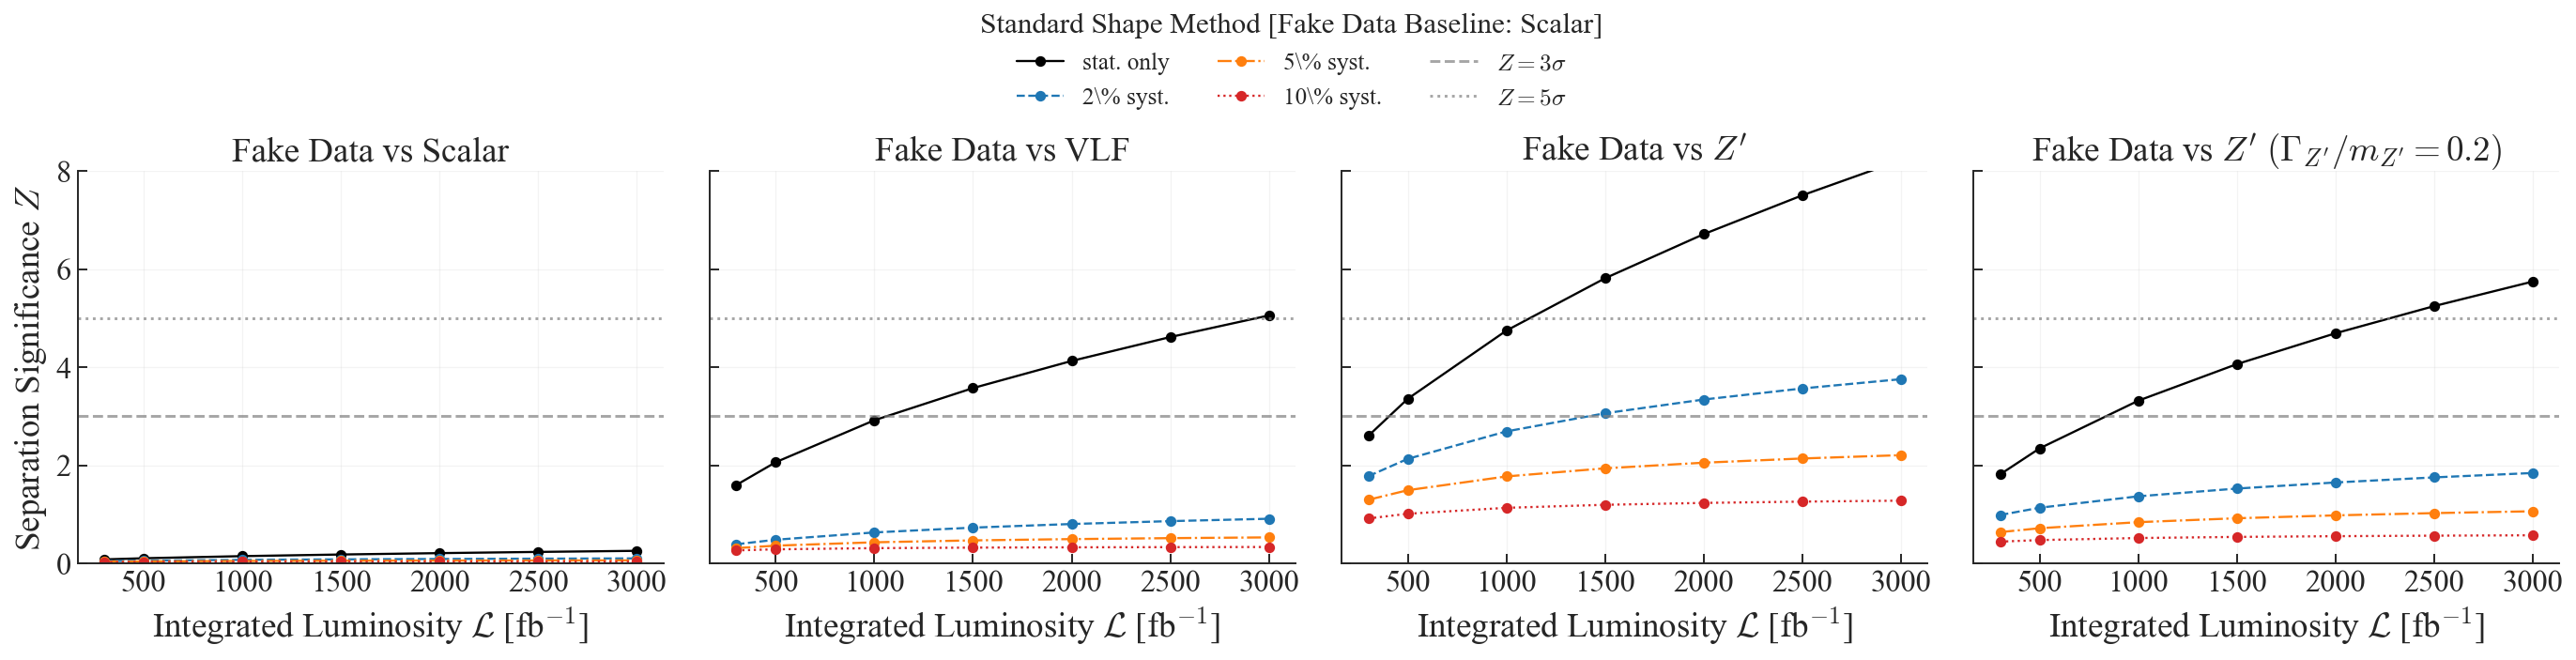

In [134]:

hp.plot_lumi_syst_grid(
    results=results_df,
    eps_values=systematics,
    outfile = './AsimovSignificance_vs_Lumi.png',
    metric="sh", # "fa" = Falloff Method, "sh" = Shape Method
    fake_model = 'Scalar'
)

# Some other plots

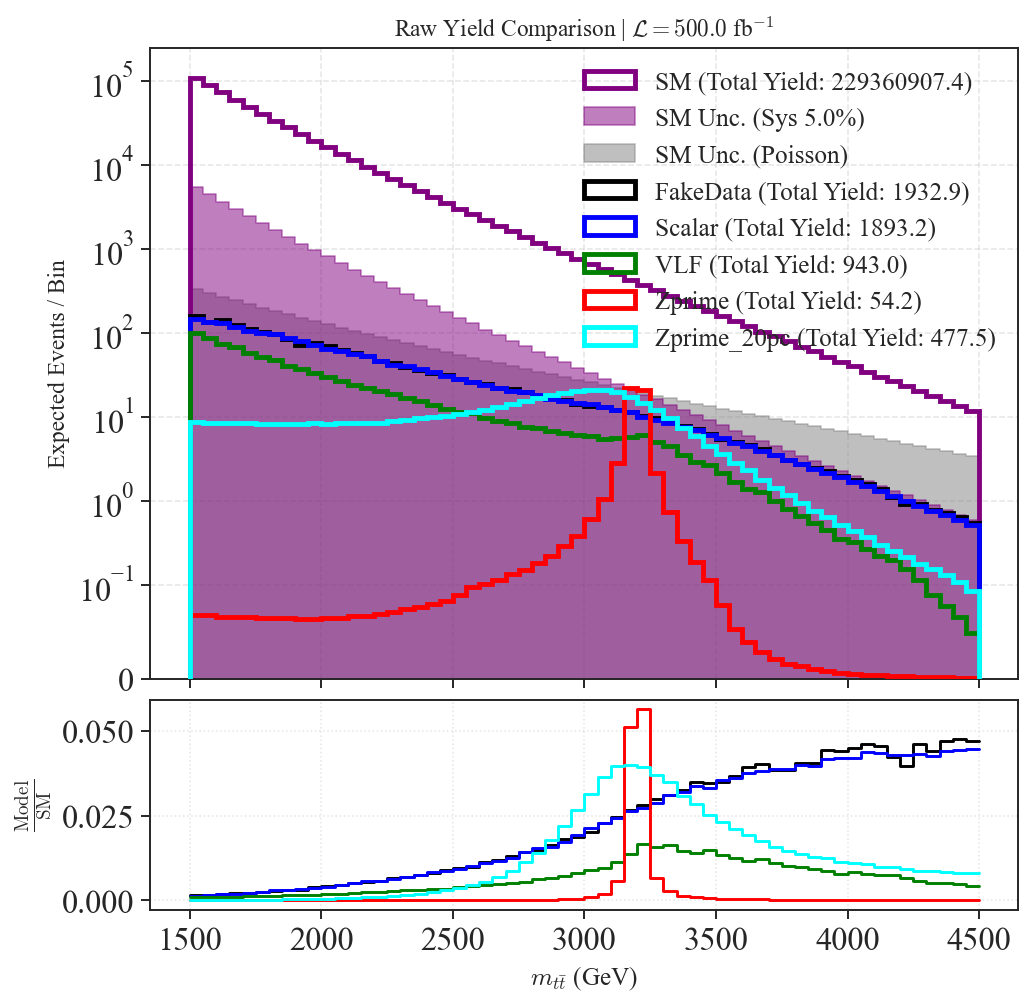

In [137]:
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_weighted_histograms(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, density=False, sys_err=0.05):
    """
    Plots superimposed 1D distributions (Main) and their ratio to SM (Sub-panel) with Error Bars.
    Distributions are plotted with their raw expected yields for the given luminosity.
    Negative weights (e.g., from NLO interference) are fully preserved.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]

    # --- Define Color Mapping Here ---
    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'Zprime_20pc': 'cyan',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}

    # Extract and Bin SM (Calculating Sum of Squared Weights for Error)
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    # Get yields and statistical variance
    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hErr_sm_poisson = np.sqrt(h_sm)
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    # Apply systematical error in the SM
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sys_err * h_sm)**2)

    hist_data['SM'] = {'h': h_sm, 'err': hErr_sm, 'err_poisson': hErr_sm_poisson, 'lbl': f"SM (Total Yield: {np.sum(w_sm):.1f})"}

    # Extract and Bin BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)

        if lab_str == 'FakeData':
            err = np.sqrt(np.abs(h))
        else:
            hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
            err = np.sqrt(hErr_stat_sq)

        hist_data[lab_str] = {'h': h, 'err': err, 'lbl': f"{lab_str} (Total Yield: {np.sum(h):.1f})"}

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # Plot lines and their ratios
    for lab_str, data in hist_data.items():

        c = color_map.get(lab_str, 'gray')

        # Plot the main step histogram
        ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                     histtype="step", linewidth=2.5, label=data['lbl'], color=c, zorder=3)

        # ============================================================
        # ONLY IN UPPER PANEL: SM Shaded Uncertainty Band
        # ============================================================
        if lab_str == 'SM':
            # Pad the arrays to match the length of bin_edges for step='post'
            h_pad = np.append(data['h'], data['h'][-1])
            err_pad = np.append(data['err'], data['err'][-1])
            err_poisson_pad = np.append(data['err_poisson'], data['err_poisson'][-1])
            ax_main.fill_between(bin_edges,
                                 0,
                                 err_pad,
                                 step='post', color=c, alpha=0.5, zorder=2,
                                 label=rf"SM Unc. (Sys {100*sys_err}%)")
            ax_main.fill_between(bin_edges,
                                 0,
                                 err_poisson_pad,
                                 step='post', color='gray', alpha=0.5, zorder=1,
                                 label=r"SM Unc. (Poisson)")

            # Baseline for the ratio panel (no shading)
            #ax_ratio.axhline(1.0, color='k', linestyle='--', alpha=0.8, zorder=1)

        # Compute and plot the ratio to SM with Error Bars
        if lab_str != 'SM':
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.where(h_sm > 0, data['h'] / h_sm, np.nan)
                ratio_err = np.where(
                    h_sm > 0,
                    (1.0 / h_sm) * np.sqrt(data['err']**2 + (ratio**2 * hErr_sm**2)),
                    np.nan
                )

            # Keep the faint step line connecting the points to match original aesthetic
            ratio_padded = np.append(ratio, ratio[-1])
            ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=1.0, zorder=3)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    ax_main.set_title(rf"Raw Yield Comparison | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$", fontsize=12)
    ax_main.set_ylabel("Density" if density else "Expected Events / Bin", fontsize=12)
    ax_main.legend(loc="best", framealpha=1.0)
    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    ax_ratio.set_xlabel(r'$m_{t\bar{t}}$ (GeV)' if var == 'm_tt' else var, fontsize=13)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Model}}{\mathrm{SM}}$", fontsize=14)
    ax_ratio.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [("m_tt", (1500, 4500))]
LUMI = 500.0

for v, rng in observables:
    plot_raw_weighted_histograms(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=rng,
        density=False,
        sys_err=0.05
    )

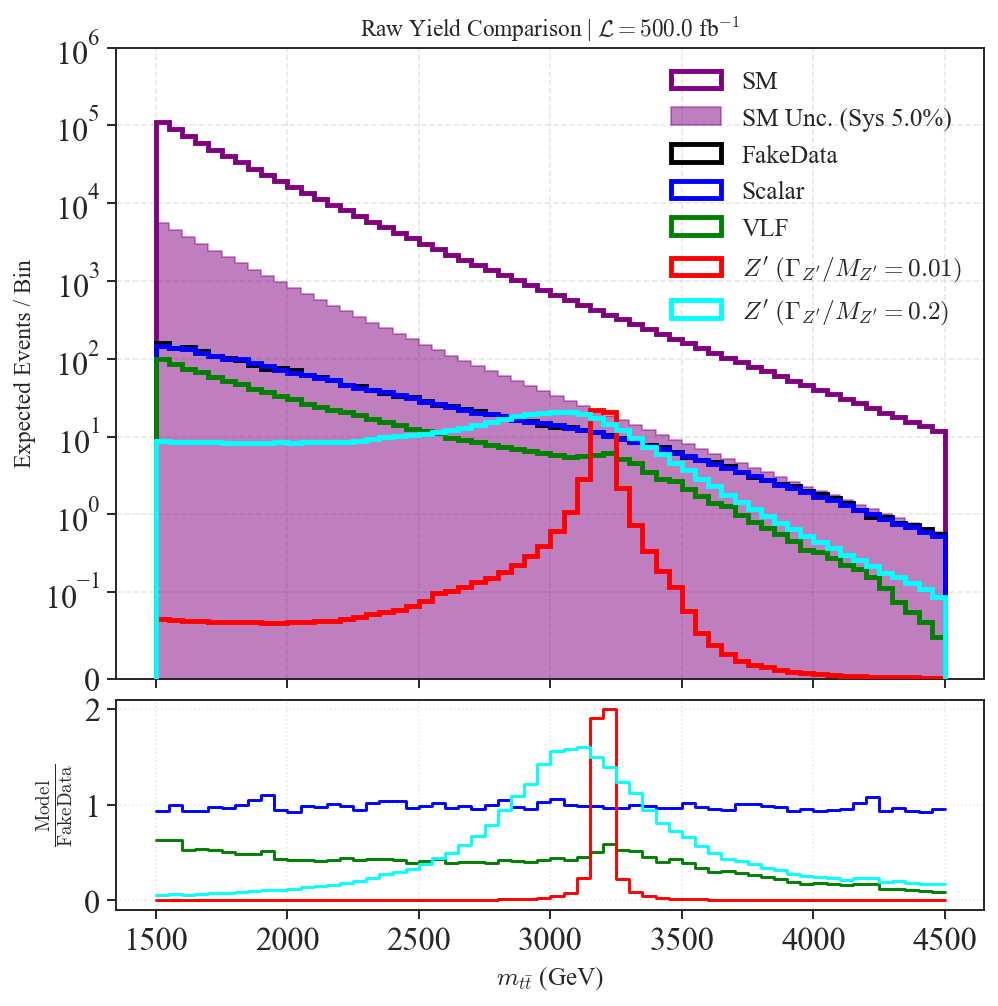

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_weighted_histograms(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, density=False, sys_err=0.05):
    """
    Plots superimposed 1D distributions (Main) and their ratio to FakeData (Sub-panel) with Error Bars.
    Distributions are plotted with their raw expected yields for the given luminosity.
    Negative weights (e.g., from NLO interference) are fully preserved.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]

    # --- Define Color Mapping Here ---
    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'Zprime_20pc': 'cyan',
        'FakeData': 'black',
        '$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.2)$': 'cyan',
        '$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.01)$': 'red'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}

    # Extract and Bin SM (Calculating Sum of Squared Weights for Error)
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    # Get yields and statistical variance
    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hErr_sm_poisson = np.sqrt(h_sm)
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    # Apply the systematical error
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sys_err * h_sm)**2)
    hist_data['SM'] = {'h': h_sm, 'err': hErr_sm, 'err_poisson': hErr_sm_poisson, 'lbl': "SM"}

    # Extract and Bin BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)

        if lab_str == 'FakeData':
            err = np.sqrt(np.abs(h))
        else:
            hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
            err = np.sqrt(hErr_stat_sq)

        if lab_str == 'Zprime_20pc':
            lab_str = r'$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.2)$'
        elif lab_str == 'Zprime':
            lab_str = r'$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.01)$'

        hist_data[lab_str] = {'h': h, 'err': err, 'lbl': lab_str}

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # Plot lines and their ratios
    for lab_str, data in hist_data.items():

        c = color_map.get(lab_str, 'gray')

        # Plot the main step histogram
        ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                     histtype="step", linewidth=2.5, label=data['lbl'], color=c, zorder=3)

        # ============================================================
        # ONLY IN UPPER PANEL: SM Shaded Uncertainty Band
        # ============================================================
        if lab_str == 'SM':
            # Pad the arrays to match the length of bin_edges for step='post'
            h_pad = np.append(data['h'], data['h'][-1])
            err_pad = np.append(data['err'], data['err'][-1])
            err_poisson_pad = np.append(data['err_poisson'], data['err_poisson'][-1])
            ax_main.fill_between(bin_edges,
                                 0,
                                 err_pad,
                                 step='post', color=c, alpha=0.5, zorder=2,
                                 label=rf"SM Unc. (Sys {100*sys_err}%)")
            #ax_main.fill_between(bin_edges,
             #                    0,
              #                   err_poisson_pad,
               #                  step='post', color='gray', alpha=0.5, zorder=1,
                #                 label=r"SM Unc. (Poisson)")

        # ============================================================
        # RATIO PANEL: Ratio of Model to FakeData
        # ============================================================
        if lab_str != 'FakeData' and 'FakeData' in hist_data:
            h_base = hist_data['FakeData']['h']
            err_base = hist_data['FakeData']['err']

            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.where(h_base > 0, data['h'] / h_base, np.nan)
                ratio_err = np.where(
                    h_base > 0,
                    (1.0 / h_base) * np.sqrt(data['err']**2 + (ratio**2 * err_base**2)),
                    np.nan
                )


            ratio_padded = np.append(ratio, ratio[-1])
            if lab_str != 'SM':
              ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=1.0, zorder=3)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    ax_main.set_title(rf"Raw Yield Comparison | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$", fontsize=12)
    ax_main.set_ylabel("Density" if density else "Expected Events / Bin", fontsize=12)
    ax_main.legend(loc="best", framealpha=1.0)
    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.set_ylim([0,1e+6])
    ax_main.grid(True, linestyle='--', alpha=0.5)

    ax_ratio.set_xlabel(r'$m_{t\bar{t}}$ (GeV)' if var == 'm_tt' else var, fontsize=13)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Model}}{\mathrm{Fake Data}}$", fontsize=14)
    ax_ratio.grid(True, linestyle=':', alpha=0.5)
    #ax_ratio.set_yscale('log')

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [("m_tt", (1500, 4500))]
LUMI = 500.0

for v, rng in observables:
    plot_raw_weighted_histograms(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=rng,
        density=False,
        sys_err=0.05
    )

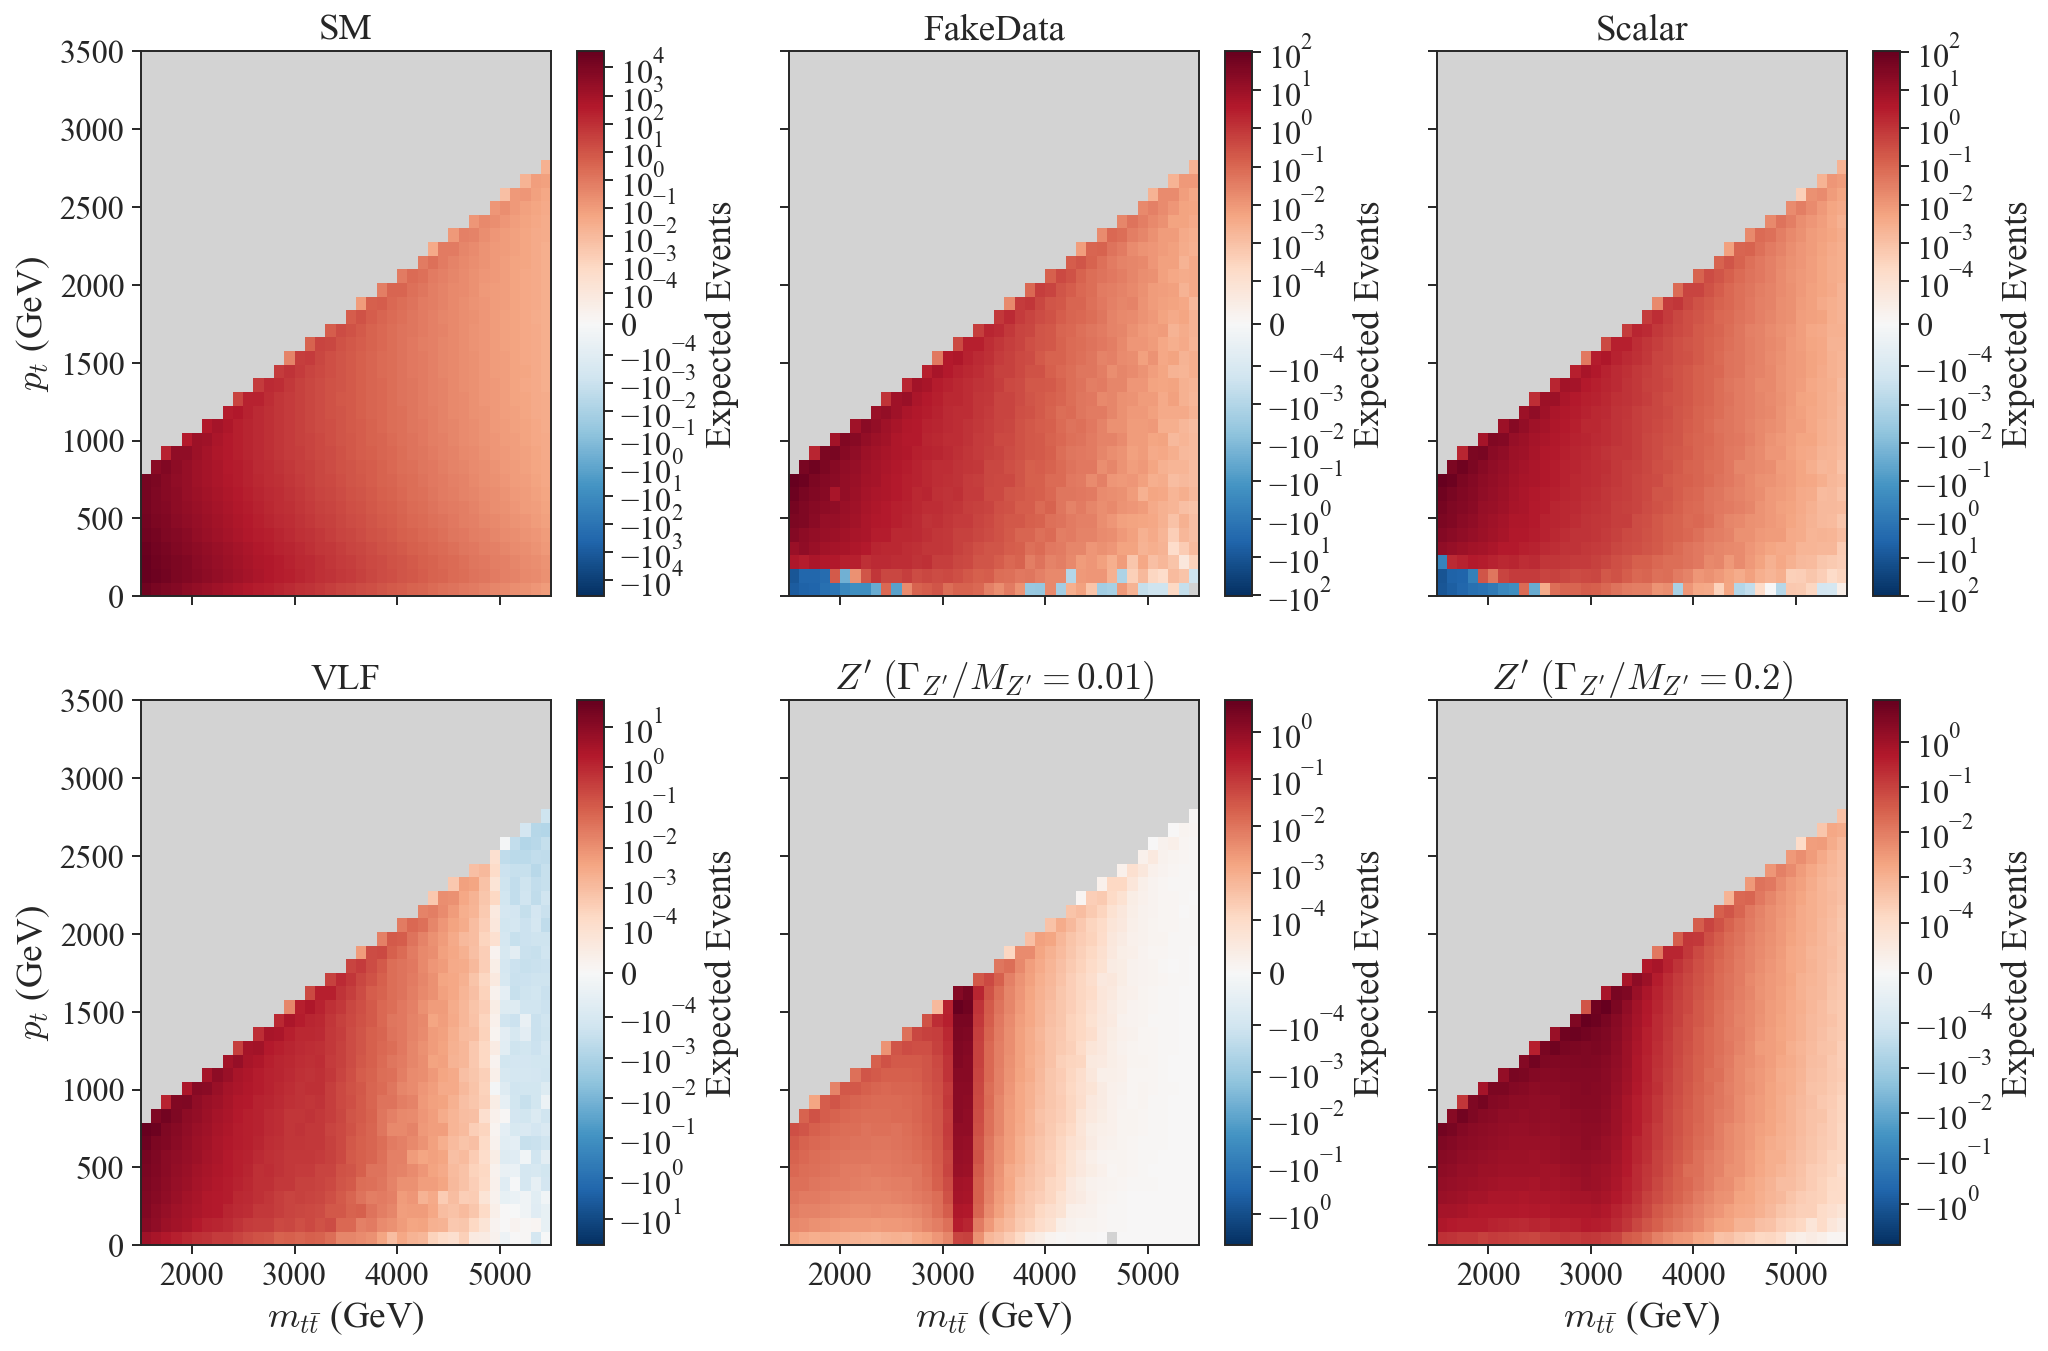

In [63]:


def plot_2d_kinematics_grid(df_bsm, df_sm, var_x, var_y, lum=500.0, bins=(40, 40), rng_x=None, rng_y=None):
    label_col = "label" if "label" in df_bsm.columns else "model"
    target_models = ["SM", "FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]

    # Setup grid dimensions (e.g., 2 rows x 3 columns for 6 models)
    n_models = len(target_models)
    cols = 3
    rows = math.ceil(n_models / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, model in enumerate(target_models):
        ax = axes[i]

        # Extract data based on model
        if model == "SM":
            df_clean = df_sm[[var_x, var_y, 'weight']].replace([np.inf, -np.inf], np.nan).dropna()
        else:
            df_model = df_bsm[df_bsm[label_col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x)) == model]
            df_clean = df_model[[var_x, var_y, 'weight']].replace([np.inf, -np.inf], np.nan).dropna()

        if df_clean.empty:
            ax.set_visible(False)
            continue

        x = df_clean[var_x].values
        y = df_clean[var_y].values
        w = df_clean['weight'].values * lum * 1000.0

        # Define ranges
        rx = rng_x if rng_x else (x.min(), x.max())
        ry = rng_y if rng_y else (y.min(), y.max())

        # Compute histogram manually to define symmetric color boundaries
        hist, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[rx, ry], weights=w)

        # Mask exact zeros: Treat empty bins as missing data rather than numerical zero
        hist_masked = np.ma.masked_where(hist == 0, hist)

        # Find the maximum absolute value to center the colormap at exactly 0
        max_val = np.nanmax(np.abs(hist))
        if max_val == 0 or np.isnan(max_val):
            max_val = 1.0

        # Create a copy of the colormap to modify its "bad" (masked) data color
        cmap = plt.get_cmap('RdBu_r').copy()
        cmap.set_bad(color='lightgray') # Empty bins will be distinct gray

        # Plot using pcolormesh with the masked histogram and updated colormap
        pcm = ax.pcolormesh(
            xedges, yedges, hist_masked.T,
            cmap=cmap,
            norm=mcolors.SymLogNorm(linthresh=1e-4, vmin=-max_val, vmax=max_val, base=10)
        )
        if model == 'Zprime':
            ax.set_title(r"$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.01)$")
        elif model == 'Zprime_20pc':
            ax.set_title(r"$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.2)$")
        else:
          ax.set_title(rf"{model}")
        fig.colorbar(pcm, ax=ax, label="Expected Events")

        # Formatting
        if i >= len(axes) - cols:
            ax.set_xlabel(r'$m_{t\bar{t}}$ (GeV)' if var_x == 'm_tt' else var_x)
        if i % cols == 0:
            ax.set_ylabel(r'$p_{t}$ (GeV)' if var_y in ['p_t', 'pT'] else var_y)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('pt_vs_mtt_2D.png', dpi = 300)
    plt.show()

# Execution
plot_2d_kinematics_grid(df_bsm, df_sm, var_x='m_tt', var_y='pT', rng_x=(1500, 5500), rng_y=(0, 3500))

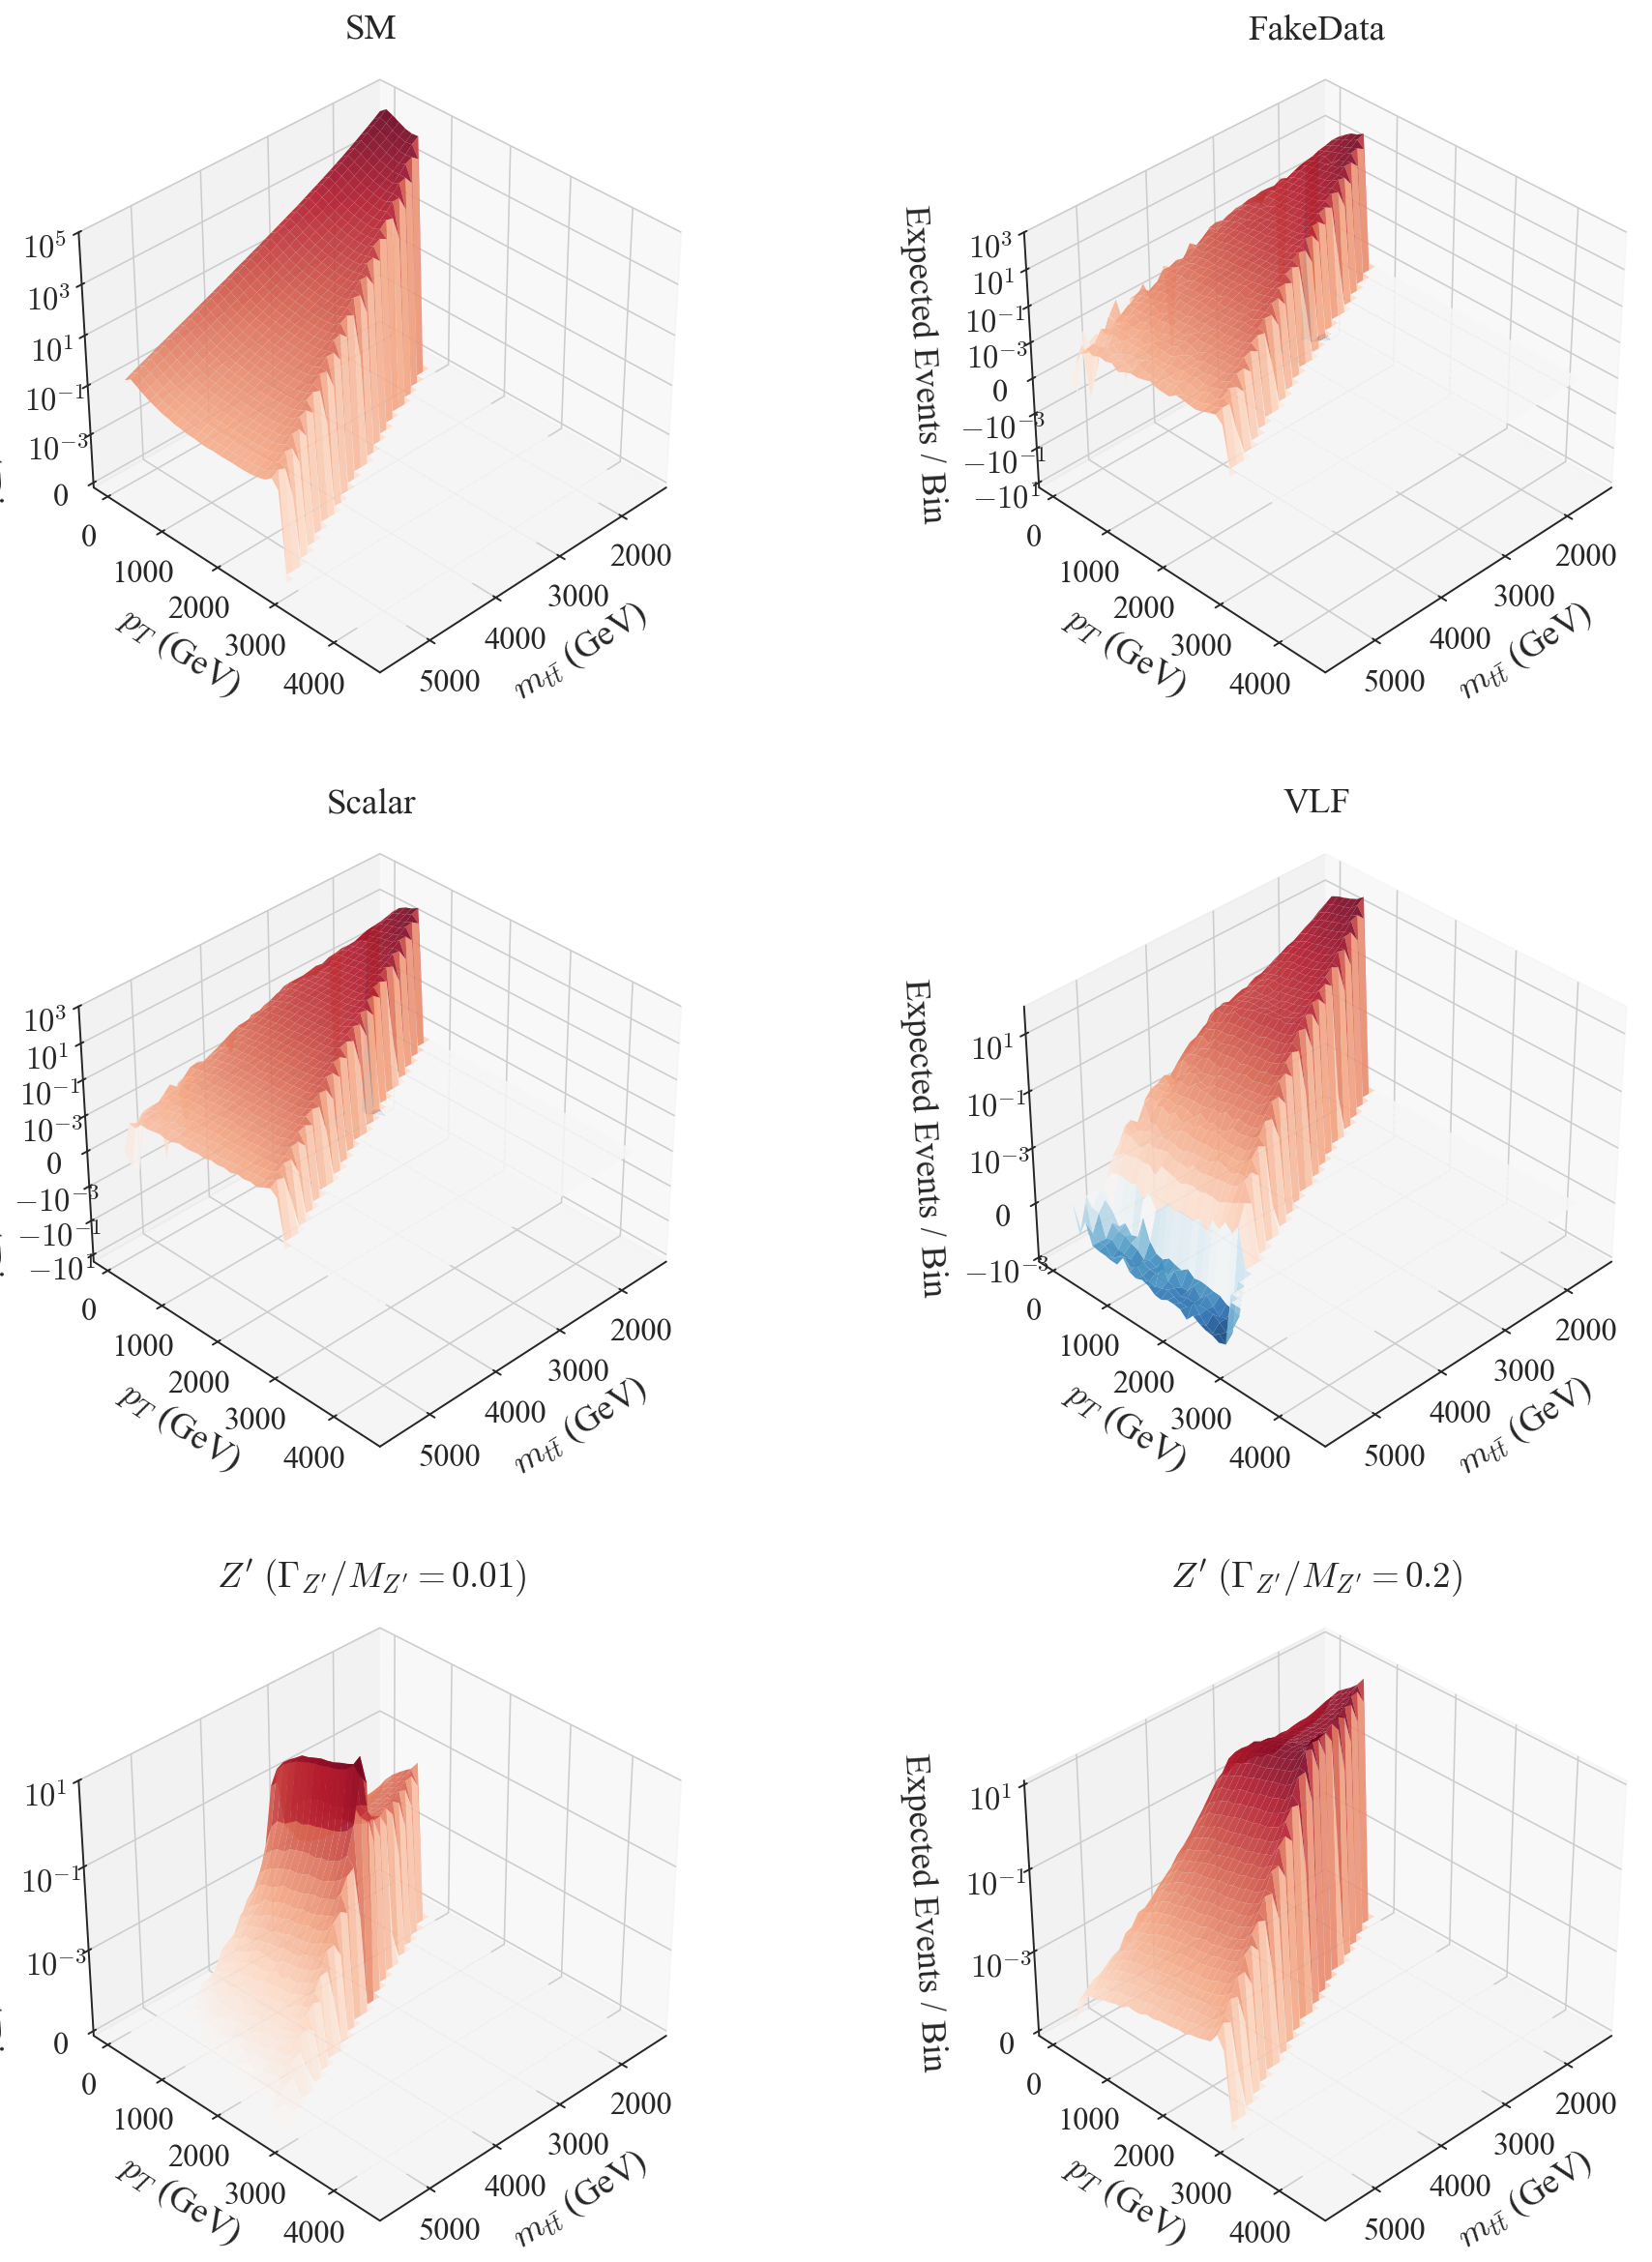

In [111]:
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_kinematics_grid(df_bsm, df_sm, var_x, var_y, lum=500.0, bins=(40, 40), rng_x=None, rng_y=None):
    label_col = "label" if "label" in df_bsm.columns else "model"
    target_models = ["SM", "FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]

    n_models = len(target_models)
    cols = 2
    rows = math.ceil(n_models / cols)

    fig = plt.figure(figsize=(16, 6 * rows))

    linthresh = 1e-5
    min_log = np.log10(linthresh)

    for i, model in enumerate(target_models):
        ax = fig.add_subplot(rows, cols, i + 1, projection='3d')

        if model == "SM":
            df_clean = df_sm[[var_x, var_y, 'weight']].replace([np.inf, -np.inf], np.nan).dropna()
        else:
            df_model = df_bsm[df_bsm[label_col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x)) == model]
            df_clean = df_model[[var_x, var_y, 'weight']].replace([np.inf, -np.inf], np.nan).dropna()

        if df_clean.empty:
            ax.set_axis_off()
            continue

        x = df_clean[var_x].values
        y = df_clean[var_y].values
        w = df_clean['weight'].values * lum * 1000.0

        rx = rng_x if rng_x else (x.min(), x.max())
        ry = rng_y if rng_y else (y.min(), y.max())

        hist, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[rx, ry], weights=w)

        abs_hist = np.clip(np.abs(hist), linthresh, None)
        hist_symlog = np.sign(hist) * (np.log10(abs_hist) - min_log)

        x_centers = (xedges[:-1] + xedges[1:]) / 2
        y_centers = (yedges[:-1] + yedges[1:]) / 2
        X, Y = np.meshgrid(x_centers, y_centers)
        Z = hist_symlog.T

        z_min = np.nanmin(Z)
        z_max = np.nanmax(Z)
        if z_min >= 0: z_min = -0.1
        if z_max <= 0: z_max = 0.1
        norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=z_min, vmax=z_max)

        surf = ax.plot_surface(X, Y, Z, cmap='RdBu_r', norm=norm, edgecolor='none', alpha=0.9)

        if model == 'Zprime':
            ax.set_title(r"$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.01)$")
        elif model == 'Zprime_20pc':
            ax.set_title(r"$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.2)$")
        else:
            ax.set_title(rf"{model}")

        ax.set_xlabel(r'$m_{t\bar{t}}$ (GeV)' if var_x == 'm_tt' else var_x, labelpad=10)
        ax.set_ylabel(r'$p_{T}$ (GeV)' if var_y == 'pT' else var_y, labelpad=10)

        ax.set_zlabel("Expected Events / Bin", labelpad=12)

        max_val_data = np.nanmax(hist)
        min_val_data = np.nanmin(hist)

        tick_locs = [0]
        tick_labels = ["0"]

        if max_val_data > linthresh:
            for exp in range(int(min_log) + 2, int(np.ceil(np.log10(max_val_data))) + 1, 2):
                tick_locs.append(exp - min_log)
                tick_labels.append(rf"$10^{{{exp}}}$")

        if min_val_data < -linthresh:
            for exp in range(int(min_log) + 2, int(np.ceil(np.log10(np.abs(min_val_data)))) + 1, 2):
                tick_locs.append(-(exp - min_log))
                tick_labels.append(rf"$-10^{{{exp}}}$")

        sorted_indices = np.argsort(tick_locs)
        ax.set_zticks(np.array(tick_locs)[sorted_indices])
        ax.set_zticklabels(np.array(tick_labels)[sorted_indices])

        ax.tick_params(axis='z', pad=2)
        ax.dist = 14
        ax.view_init(elev=35, azim=45)


    fig.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0.20, hspace=0.20)

    plt.savefig('pt_vs_mtt_3D.png', dpi=300)
    plt.show()

# Execution
plot_3d_kinematics_grid(df_bsm, df_sm, var_x='m_tt', var_y='pT', rng_x=(1500, 5500), rng_y=(0, 4500))

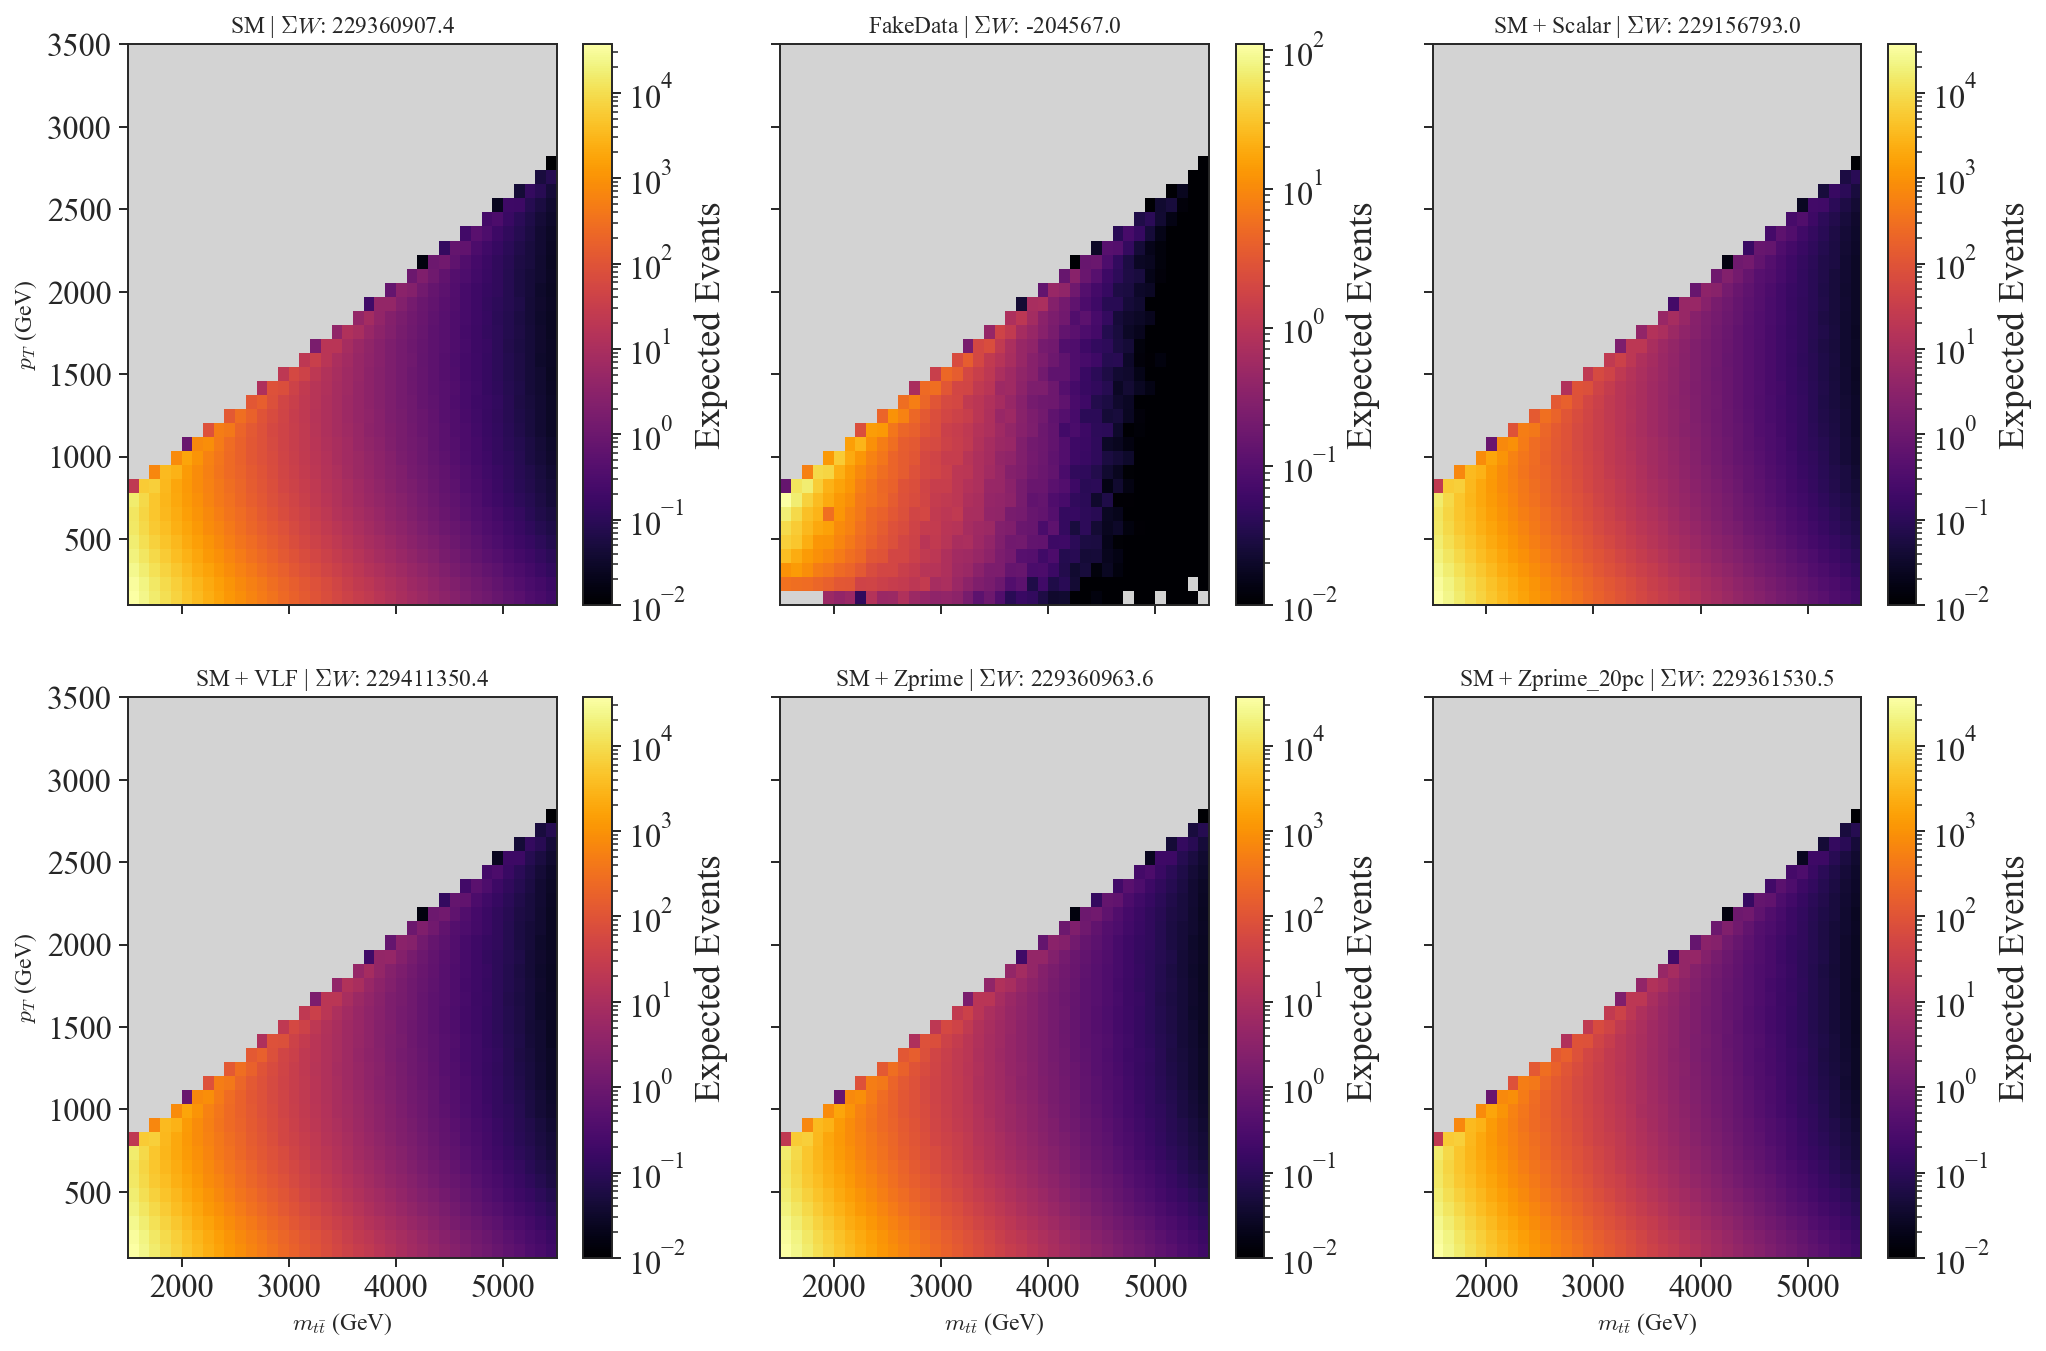

In [22]:


def plot_2d_kinematics_grid(df_bsm, df_sm, var_x, var_y, lum=500.0, bins=(40, 40), rng_x=None, rng_y=None):
    label_col = "label" if "label" in df_bsm.columns else "model"
    target_models = ["SM", "FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]

    # Setup grid dimensions
    n_models = len(target_models)
    cols = 3
    rows = math.ceil(n_models / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), sharex=True, sharey=True)
    axes = axes.flatten()

    # 1. Pre-calculate SM Data & Histogram
    df_sm_clean = df_sm[[var_x, var_y, 'weight']].replace([np.inf, -np.inf], np.nan).dropna()
    x_sm = df_sm_clean[var_x].values
    y_sm = df_sm_clean[var_y].values
    w_sm = df_sm_clean['weight'].values * lum * 1000.0

    # Establish a fixed global range so SM and BSM histograms align perfectly for addition
    rx = rng_x if rng_x else (x_sm.min(), x_sm.max())
    ry = rng_y if rng_y else (y_sm.min(), y_sm.max())

    hist_sm, xedges, yedges = np.histogram2d(x_sm, y_sm, bins=bins, range=[rx, ry], weights=w_sm)
    total_sm_yield = np.sum(w_sm)

    for i, model in enumerate(target_models):
        ax = axes[i]

        if model == "SM":
            hist_plot = hist_sm
            title = rf"SM | $\Sigma W$: {total_sm_yield:.1f}"
        else:
            # Extract BSM data
            df_model = df_bsm[df_bsm[label_col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x)) == model]
            df_clean = df_model[[var_x, var_y, 'weight']].replace([np.inf, -np.inf], np.nan).dropna()

            if df_clean.empty:
                ax.set_visible(False)
                continue

            x_model = df_clean[var_x].values
            y_model = df_clean[var_y].values
            w_model = df_clean['weight'].values * lum * 1000.0

            # Compute BSM histogram using the exact same bins/ranges as the SM histogram
            hist_model, _, _ = np.histogram2d(x_model, y_model, bins=bins, range=[rx, ry], weights=w_model)

            if model == "FakeData":
                # FakeData is already total pseudo-data, do not add SM to it
                hist_plot = hist_model
                title = rf"{model} | $\Sigma W$: {np.sum(w_model):.1f}"
            else:
                # Add SM background to the BSM signal/interference
                hist_plot = hist_sm + hist_model
                title = rf"SM + {model} | $\Sigma W$: {(total_sm_yield + np.sum(w_model)):.1f}"

        # MASK ZERO OR NEGATIVE BINS: LogNorm can't handle them, and we want them distinct
        hist_masked = np.ma.masked_where(hist_plot <= 0, hist_plot)

        # Create a copy of the colormap to modify its "bad" (masked) data color
        cmap = plt.get_cmap('inferno').copy()
        cmap.set_bad(color='lightgray') # Empty/forbidden kinematic bins will be gray

        #  Plot using standard LogNorm with the updated colormap
        pcm = ax.pcolormesh(
            xedges, yedges, hist_masked.T,
            cmap=cmap,
            norm=mcolors.LogNorm(vmin=1e-2, vmax=np.nanmax(hist_plot))
        )

        ax.set_title(title, fontsize=12)
        fig.colorbar(pcm, ax=ax, label="Expected Events")

        # Formatting
        if i >= len(axes) - cols:
            ax.set_xlabel(r'$m_{t\bar{t}}$ (GeV)' if var_x == 'm_tt' else var_x, fontsize=12)
        if i % cols == 0:
            ax.set_ylabel(r'$p_{T}$ (GeV)' if var_y in ['p_t', 'pT'] else var_y, fontsize=12)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# Execution
plot_2d_kinematics_grid(df_bsm, df_sm, var_x='m_tt', var_y='pT', rng_x=(1500, 5500), rng_y=(100, 3500))

# Shape Analysis with statistics

$$Z_{\rm syst}^2
\;\approx\;
\sum_k
\frac{\left(n_k^{(A)}-n_k^{(B)}\right)^2}
{n_k^{\rm ref}+\left(\varepsilon\, n_k^{\rm ref}\right)^2} $$




## The below cell is the Asimov significance in function of the cut in $m_{t\bar{t}}$

In [130]:
import helpers as hp
importlib.reload(hp)

<module 'helpers' from '/content/helpers.py'>